# 📌 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns

# 📌 2. Load Data
data = pd.read_csv('car_price_prediction_dataset.csv')

# 📌 3. Basic Exploration
print(data.info())
print(data.describe())
print(data.isnull().sum())

# 📌 4. Fill Missing Values
for col in data.select_dtypes(include=np.number).columns:
    data[col].fillna(data[col].median(), inplace=True)

for col in data.select_dtypes(exclude=np.number).columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

# 📌 5. Drop Duplicates
data.drop_duplicates(inplace=True)

# 📌 6. Encode Categorical Columns
label_encoders = {}
categorical_cols = ['Brand', 'Fuel_Type', 'Transmission']

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# 📌 7. Outlier Removal Using IQR
numeric_cols = data.select_dtypes(include=np.number).columns
mask = pd.Series(True, index=data.index)

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask &= data[col].between(lower_bound, upper_bound)

data_cleaned = data[mask]

# 📌 8. Split Data
X = data_cleaned.drop('Price_Lakhs', axis=1)
y = data_cleaned['Price_Lakhs']

# 📌 9. Feature Scaling (Standardization)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# 📌 10. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 📌 11. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 📌 12. Predict
y_pred = model.predict(X_test)

# 📌 13. Evaluation
df_preds = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print(df_preds.head(10))

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n📊 Mean Absolute Error: {mae:.2f}")
print(f"📉 Root Mean Squared Error: {rmse:.2f}")

# 📌 14. Visualization
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# 📌 15. Predict User Input
def predict_car_price():
    print("\nEnter car details for price prediction:")

    for i, brand in enumerate(label_encoders['Brand'].classes_):
        print(f"{i}: {brand}")
    brand_input = int(input("Enter Brand number: "))

    year = int(input("Model Year (e.g. 2015): "))

    for i, fuel in enumerate(label_encoders['Fuel_Type'].classes_):
        print(f"{i}: {fuel}")
    fuel_input = int(input("Enter Fuel Type number: "))

    for i, trans in enumerate(label_encoders['Transmission'].classes_):
        print(f"{i}: {trans}")
    trans_input = int(input("Enter Transmission number: "))

    kms = float(input("Kilometers Driven: "))
    engine = float(input("Engine CC: "))
    seats = float(input("Number of Seats: "))

    new_car = pd.DataFrame([[brand_input, year, fuel_input, trans_input, kms, engine, seats]],
                           columns=X.columns)
    new_car_scaled = scaler.transform(new_car)

    predicted_price = model.predict(new_car_scaled)[0]
    print(f"\n🚗 Predicted Price: Rs {predicted_price:.2f} Lakhs")

# Uncomment to run the prediction function
predict_car_price()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        200 non-null    int64  
 1   Brand         200 non-null    object 
 2   Model_Year    200 non-null    int64  
 3   Fuel_Type     200 non-null    object 
 4   Transmission  200 non-null    object 
 5   KMs_Driven    180 non-null    float64
 6   Engine_CC     180 non-null    float64
 7   Seats         180 non-null    float64
 8   Price_Lakhs   200 non-null    float64
dtypes: float64(4), int64(2), object(3)
memory usage: 14.2+ KB
None
           Car_ID   Model_Year     KMs_Driven    Engine_CC       Seats  \
count  200.000000   200.000000     180.000000   180.000000  180.000000   
mean   100.500000  2010.905000  104292.411111  2032.311111    5.522222   
std     57.879185     7.195474   53970.532584   667.355720    1.085483   
min      1.000000  2000.000000   10404.000000   803.000000 

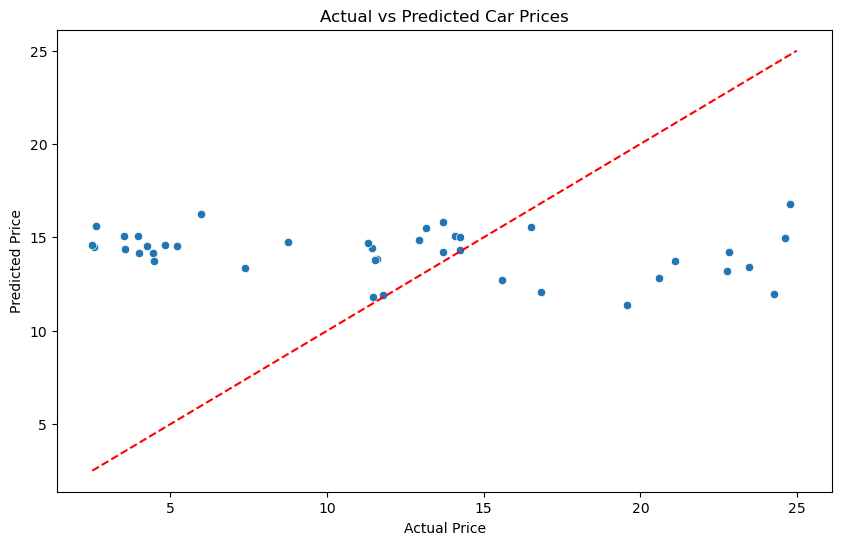


Enter car details for price prediction:
0: BMW
1: Ford
2: Honda
3: Hyundai
4: Toyota
Enter Brand number: 2
Model Year (e.g. 2015): 2
0: Diesel
1: Electric
2: Hybrid
3: Petrol
Enter Fuel Type number: 2
0: Automatic
1: Manual
Enter Transmission number: 


ValueError: invalid literal for int() with base 10: ''

In [6]:
# 📌 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns

# 📌 2. Load Data
data = pd.read_csv('car_price_prediction_dataset.csv')

# 📌 3. Basic Exploration
print(data.info())
print(data.describe())
print(data.isnull().sum())

# 📌 4. Fill Missing Values
for col in data.select_dtypes(include=np.number).columns:
    data[col].fillna(data[col].median(), inplace=True)

for col in data.select_dtypes(exclude=np.number).columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

# 📌 5. Drop Duplicates
data.drop_duplicates(inplace=True)

# 📌 6. Encode Categorical Columns
label_encoders = {}
categorical_cols = ['Brand', 'Fuel_Type', 'Transmission']

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# 📌 7. Outlier Removal Using IQR
numeric_cols = data.select_dtypes(include=np.number).columns
mask = pd.Series(True, index=data.index)

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask &= data[col].between(lower_bound, upper_bound)

data_cleaned = data[mask]

# 📌 8. Split Data
X = data_cleaned.drop('Price_Lakhs', axis=1)
y = data_cleaned['Price_Lakhs']

# 📌 9. Feature Scaling (Standardization)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# 📌 10. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 📌 11. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 📌 12. Predict
y_pred = model.predict(X_test)

# 📌 13. Evaluation
df_preds = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print(df_preds.head(10))

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n📊 Mean Absolute Error: {mae:.2f}")
print(f"📉 Root Mean Squared Error: {rmse:.2f}")

# 📌 14. Visualization
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

# 📌 15. Predict User Input
def predict_car_price():
    print("\nEnter car details for price prediction:")

    for i, brand in enumerate(label_encoders['Brand'].classes_):
        print(f"{i}: {brand}")
    brand_input = int(input("Enter Brand number: "))

    year = int(input("Model Year (e.g. 2015): "))

    for i, fuel in enumerate(label_encoders['Fuel_Type'].classes_):
        print(f"{i}: {fuel}")
    fuel_input = int(input("Enter Fuel Type number: "))

    for i, trans in enumerate(label_encoders['Transmission'].classes_):
        print(f"{i}: {trans}")
    trans_input = int(input("Enter Transmission number: "))

    kms = float(input("Kilometers Driven: "))
    engine = float(input("Engine CC: "))
    seats = float(input("Number of Seats: "))

    new_car = pd.DataFrame([[brand_input, year, fuel_input, trans_input, kms, engine, seats]],
                           columns=X.columns)
    new_car_scaled = scaler.transform(new_car)

    predicted_price = model.predict(new_car_scaled)[0]
    print(f"\n🚗 Predicted Price: Rs {predicted_price:.2f} Lakhs")

# Uncomment to run the prediction function
predict_car_price()


In [7]:
 # 5. Linear Regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

plt.figure(figsize=(12, 8))
plt.scatter(x=data_scaled['KMs_Driven'], y=data_scaled['Price_Lakhs'])
plt.title('Scatterplot of Kilometers Driven vs Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Price (in Lakhs)')
plt.show()

X = data_cleaned.drop(['Car_ID', 'Price_Lakhs'], axis=1).values
y = data_cleaned['Price_Lakhs'].values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


regressor = LinearRegression()
regressor.fit(X_train, y_train)


print("\nModel intercept:", regressor.intercept_)
print("Model coefficients:", regressor.coef_)


y_pred = regressor.predict(X_test)


df_preds = pd.DataFrame({'Actual': y_test.squeeze(), 'Predicted': y_pred.squeeze()})
print("\nActual vs Predicted prices:")
print(df_preds.head(10))

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nModel Performance Metrics:")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

NameError: name 'data_scaled' is not defined

<Figure size 1200x800 with 0 Axes>

In [9]:
## Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data=pd.read_csv('car_price_prediction_dataset.csv')

## 1. Reading data by Pandas Simple Operations

data.sample()

data.head()

data.tail()

## Checking Data Types  and Information

data.dtypes

data.describe()

data.info()

## 2. Data Cleaning

## Checking Null Values

data.isnull().sum()

__Separate numeric and non-numeric columns__

numeric_cols=data.select_dtypes(include=[np.number])
non_numeric_cols=data.select_dtypes(exclude=[np.number])

__Fill missing values in numeric columns with the mean and non_numeric by mode__

numeric_cols.fillna(numeric_cols.mean(),inplace=True)
non_numeric_cols.fillna(non_numeric_cols.mode(),inplace=True)


__Combine back with non-numeric columns__

data=pd.concat([numeric_cols,non_numeric_cols],axis=1)

data.isnull().sum()

## Droping Missing Values and Duplicate values


__In this case there is no missing value column so we do not do this process__

# data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

## Checking shape of data

data.shape



numeric_cols = data.select_dtypes(include=['float64']).columns
mask = pd.Series(True, index=data.index)

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = mask & data[col].between(lower_bound, upper_bound)

data_cleaned = data[mask]


__Visualizing the data before outlier removal__

plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
data.boxplot()
plt.title("Before Outliers removal")
plt.tight_layout()
plt.show()

## Removing Outliers

__Visualizing the data after outlier removal__

plt.figure(figsize=(30,6))
plt.subplot(1,2,1)
data_cleaned.boxplot()
plt.title("After Outliers removal")
plt.tight_layout()
plt.show()

# 4. Data Transformation


from sklearn.preprocessing import MinMaxScaler
numeric_cols = data.select_dtypes(include=['float64']).columns
numeric_data = data[numeric_cols]
scaler = MinMaxScaler()
scaled_numeric_data = scaler.fit_transform(numeric_data)
scaled_numeric_data = pd.DataFrame(scaled_numeric_data, columns=numeric_cols)
non_numeric_data = data.drop(columns=numeric_cols).reset_index(drop=True)
scaled_data = pd.concat([scaled_numeric_data, non_numeric_data], axis=1)
print(scaled_data.shape)
print()
print('*' * 60)
scaled_data.head()



from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numeric_cols = data_cleaned.select_dtypes(include=['float64', 'int64']).columns
data_scaled = pd.DataFrame(scaler.fit_transform(data_cleaned[numeric_cols]), columns=numeric_cols)
plt.figure(figsize=(16, 6))
data_scaled.boxplot()
plt.title("📊 Boxplot After Outlier Removal and Standardization")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()







# 5. Linear Regression


SyntaxError: invalid syntax (2296596424.py, line 31)